# ECG Data Exploration

This notebook focuses on **loading, visualizing, and exploring raw ECG data** from the MIT-BIH database.

## Content:
1. Setup & Import Libraries
2. Load MIT-BIH Records
3. Display Record Information & Lead Table
4. Plot Raw ECG Signal
5. R-peak Detection (Annotation & Algorithm)
6. Beat Extraction & Visualization
7. QRS Feature Extraction

## 1. Setup & Import Libraries

In [1]:
# Import thư viện cần thiết
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, welch, find_peaks
from collections import Counter

## 2. Load MIT-BIH Records

In [2]:
# Danh sách record MIT-BIH
records = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115", "116", "117", "118", "119",
    "121", "122", "123", "124",
    "200", "201", "202", "203", "205", "207", "208", "209",
    "210", "212", "213", "214", "215", "217", "219", "220",
    "221", "222", "223", "228", "230", "231", "232", "233", "234"
]

records_1xx = [r for r in records if r.startswith("1")]
records_2xx = [r for r in records if r.startswith("2")]

print("Total records:", len(records))
print("1xx records:", len(records_1xx))
print("2xx records:", len(records_2xx))

Total records: 48
1xx records: 23
2xx records: 25


In [3]:
# Load các record 1xx (ví dụ)
ecg_data = {}

for rec in records_1xx:
    try:
        record = wfdb.rdrecord(rec, pn_dir='mitdb')
        ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

        ecg_data[rec] = {
            "signal": record.p_signal[:, 0],  # MLII
            "fs": record.fs,
            "r_peaks": ann.sample,
            "labels": ann.symbol
        }

        print(f"Loaded record {rec}")

    except Exception as e:
        print(f"Failed to load record {rec}: {e}")

Loaded record 100
Loaded record 101
Loaded record 102
Loaded record 103
Loaded record 104
Loaded record 105
Loaded record 106
Loaded record 107
Loaded record 108
Loaded record 109
Loaded record 111
Loaded record 112
Loaded record 113
Loaded record 114
Loaded record 115
Loaded record 116
Loaded record 117
Loaded record 118
Loaded record 119
Loaded record 121
Loaded record 122
Loaded record 123
Loaded record 124


In [4]:
# Kiểm tra dữ liệu đã tải
print("Keys in ecg_data['100']:", ecg_data['100'].keys())
print("Signal length:", len(ecg_data['100']['signal']))
print("Number of R-peaks:", len(ecg_data['100']['r_peaks']))

Keys in ecg_data['100']: dict_keys(['signal', 'fs', 'r_peaks', 'labels'])
Signal length: 650000
Number of R-peaks: 2274


## 3. Display Record Information & Lead Table

In [5]:
# Thông tin chi tiết record 100
db_name = "mitdb"
record_name = "100"

header = wfdb.rdheader(record_name, pn_dir=db_name)

info_df = pd.DataFrame({
    "Field": [
        "Record name",
        "Number of leads",
        "Sampling rate (Hz)",
        "Number of samples",
        "Lead names"
    ],
    "Value": [
        header.record_name,
        header.n_sig,
        int(header.fs),
        header.sig_len,
        ", ".join(header.sig_name)
    ]
})

display(info_df)

,Field,Value
0,Record name,100
1,Number of leads,2
2,Sampling rate (Hz),360
3,Number of samples,650000
4,Lead names,"MLII, V5"


In [6]:
# Bảng lead của các record 1xx
lead_rows_1xx = []

for rec in records_1xx:
    h = wfdb.rdheader(rec, pn_dir=db_name)

    lead_rows_1xx.append({
        "Record (1xx)": rec,
        "Channel 1 Lead": h.sig_name[0],
        "Channel 2 Lead": h.sig_name[1]
    })

lead_1xx_df = pd.DataFrame(lead_rows_1xx)
display(lead_1xx_df)

,Record (1xx),Channel 1 Lead,Channel 2 Lead
0,100,MLII,V5
1,101,MLII,V1
2,102,V5,V2
3,103,MLII,V2
4,104,V5,V2
5,105,MLII,V1
6,106,MLII,V1
7,107,MLII,V1
8,108,MLII,V1
9,109,MLII,V1


In [7]:
# Bảng lead của các record 2xx
lead_rows_2xx = []

for rec in records_2xx:
    h = wfdb.rdheader(rec, pn_dir=db_name)

    lead_rows_2xx.append({
        "Record (2xx)": rec,
        "Channel 1 Lead": h.sig_name[0],
        "Channel 2 Lead": h.sig_name[1]
    })

lead_2xx_df = pd.DataFrame(lead_rows_2xx)
display(lead_2xx_df)

,Record (2xx),Channel 1 Lead,Channel 2 Lead
0,200,MLII,V1
1,201,MLII,V1
2,202,MLII,V1
3,203,MLII,V1
4,205,MLII,V1
5,207,MLII,V1
6,208,MLII,V1
7,209,MLII,V1
8,210,MLII,V1
9,212,MLII,V1


In [8]:
# Thống kê số record có từng lead
all_leads_per_record = []

for rec in records:
    h = wfdb.rdheader(rec, pn_dir=db_name)
    unique_leads = set(h.sig_name)

    for lead in unique_leads:
        all_leads_per_record.append(lead)

lead_counter = Counter(all_leads_per_record)

lead_summary_df = pd.DataFrame({
    "Lead": list(lead_counter.keys()),
    "Record Count": list(lead_counter.values())
})

lead_summary_df["Percentage (%)"] = (
    lead_summary_df["Record Count"] / len(records) * 100
).round(2)

lead_summary_df = lead_summary_df.sort_values(
    by="Record Count",
    ascending=False
).reset_index(drop=True)

display(lead_summary_df)

,Lead,Record Count,Percentage (%)
0,MLII,46,95.83
1,V1,40,83.33
2,V5,5,10.42
3,V2,4,8.33
4,V4,1,2.08


## 4. Plot Raw ECG Signal

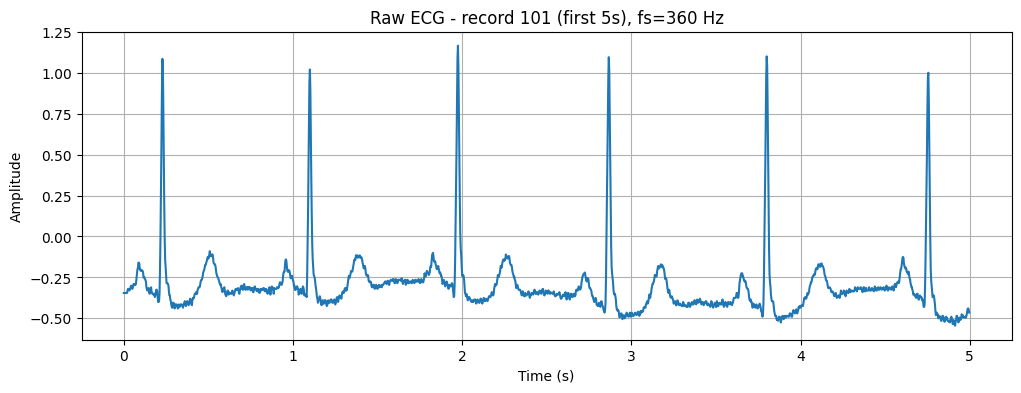

Sampling rate (fs): 360 Hz
Signal length: 650000 samples ~ 1805.5555555555557 seconds
Number of annotated R-peaks: 1874


In [9]:
# Vẽ ECG thô (ví dụ record 101, lead MLII)
rec_id = "101"      # đổi record nếu muốn
seconds = 5         # số giây muốn xem

ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]

n = min(int(seconds * fs), len(ecg_raw))
t = np.arange(n) / fs

plt.figure(figsize=(12,4))
plt.plot(t, ecg_raw[:n])
plt.title(f"Raw ECG - record {rec_id} (first {seconds}s), fs={fs} Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print("Sampling rate (fs):", fs, "Hz")
print("Signal length:", len(ecg_raw), "samples ~", len(ecg_raw)/fs, "seconds")
print("Number of annotated R-peaks:", len(ecg_data[rec_id]["r_peaks"]))

## 5. R-peak Detection (Annotation & Algorithm)

In [10]:
# Hàm helper cho R-peak detection
def bandpass_filter(x, fs, low=0.5, high=40.0, order=4):
    """Bandpass filter 0.5-40 Hz để loại bỏ baseline và high-frequency noise"""
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def detect_r_peaks_pan_tompkins_like(x, fs):
    """Pan-Tompkins-like R-peak detection algorithm"""
    # Bandpass filter nhấn mạnh QRS (~5–15Hz)
    xf = bandpass_filter(x, fs, low=5.0, high=15.0, order=2)

    # Derivative + square
    dx = np.diff(xf, prepend=xf[0])
    sq = dx ** 2

    # Moving window integrate ~150ms
    win = max(1, int(0.150 * fs))
    mwa = np.convolve(sq, np.ones(win) / win, mode="same")

    # Find peaks
    min_dist = max(1, int(0.250 * fs))  # >=250ms
    thr = np.percentile(mwa, 95) * 0.3  # threshold tương đối
    peaks, _ = find_peaks(mwa, height=thr, distance=min_dist)

    # Refine R-peaks: tìm max quanh peak trên x (±50ms)
    refined = []
    rad = max(1, int(0.050 * fs))
    for p in peaks:
        lo = max(0, p - rad)
        hi = min(len(x), p + rad + 1)
        refined.append(lo + int(np.argmax(x[lo:hi])))

    return np.unique(np.array(refined, dtype=int))

def get_r_peaks(ecg, fs, ann_r_peaks=None, mode="annotation"):
    """Get R-peaks từ annotation hoặc thuật toán detection"""
    if mode == "annotation":
        if ann_r_peaks is None:
            raise ValueError("Cần ann_r_peaks khi mode='annotation'")
        return np.asarray(ann_r_peaks, dtype=int)
    elif mode == "detect":
        return detect_r_peaks_pan_tompkins_like(ecg, fs)
    else:
        raise ValueError("mode phải là 'annotation' hoặc 'detect'")

In [11]:
# Lấy R-peaks từ annotation
rec_id = "101"
ecg_raw = ecg_data[rec_id]["signal"]
fs = ecg_data[rec_id]["fs"]
ann_r = ecg_data[rec_id]["r_peaks"]

r_peaks = get_r_peaks(ecg_raw, fs, ann_r_peaks=ann_r, mode="annotation")

print(f"Found {len(r_peaks)} R-peaks in record {rec_id}")

Found 1874 R-peaks in record 101


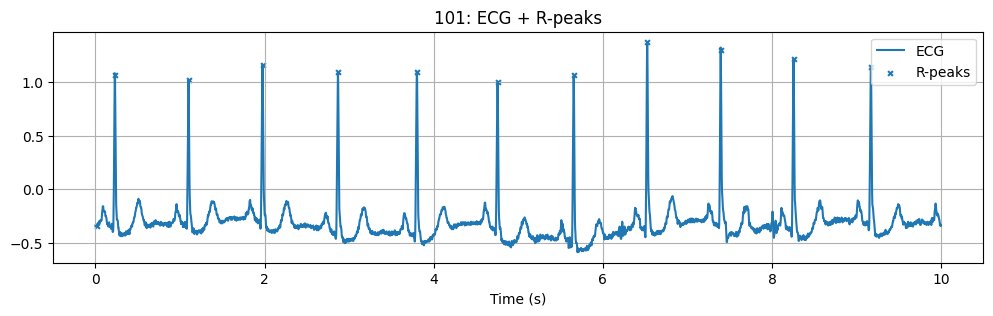

In [12]:
# Hàm vẽ ECG với R-peaks
def plot_ecg_with_r(ecg, r_peaks, fs, seconds=5, title="ECG + R-peaks"):
    """Vẽ ECG với vị trí các R-peaks được đánh dấu"""
    n = min(int(seconds * fs), len(ecg))
    t = np.arange(n) / fs
    rp = np.asarray(r_peaks, dtype=int)
    rp = rp[rp < n]

    plt.figure(figsize=(12, 3))
    plt.plot(t, ecg[:n], label="ECG")
    plt.scatter(rp / fs, ecg[rp], s=12, marker="x", label="R-peaks")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Vẽ ECG với R-peaks
plot_ecg_with_r(ecg_raw, r_peaks, fs, seconds=10, title=f"{rec_id}: ECG + R-peaks")

## 6. Beat Extraction & Visualization

In [13]:
# Cắt tất cả beats quanh R-peaks
pre_s  = 0.30   # 300 ms trước R (đủ chứa P)
post_s = 0.50   # 500 ms sau R (đủ chứa T)

pre_n  = int(pre_s * fs)
post_n = int(post_s * fs)
beat_len = pre_n + post_n

# Cắt tất cả beats
beats = []
valid_r = []

for r in r_peaks:
    r = int(r)
    if r - pre_n < 0 or r + post_n >= len(ecg_raw):
        continue
    beats.append(ecg_raw[r - pre_n : r + post_n])
    valid_r.append(r)

beats = np.array(beats)   # shape: (num_beats, beat_len)
print("Number of beats:", beats.shape[0])
print("Beat length (samples):", beats.shape[1])

# Time axis (R tại 0s)
t_beat = (np.arange(beat_len) - pre_n) / fs

Number of beats: 1872
Beat length (samples): 288


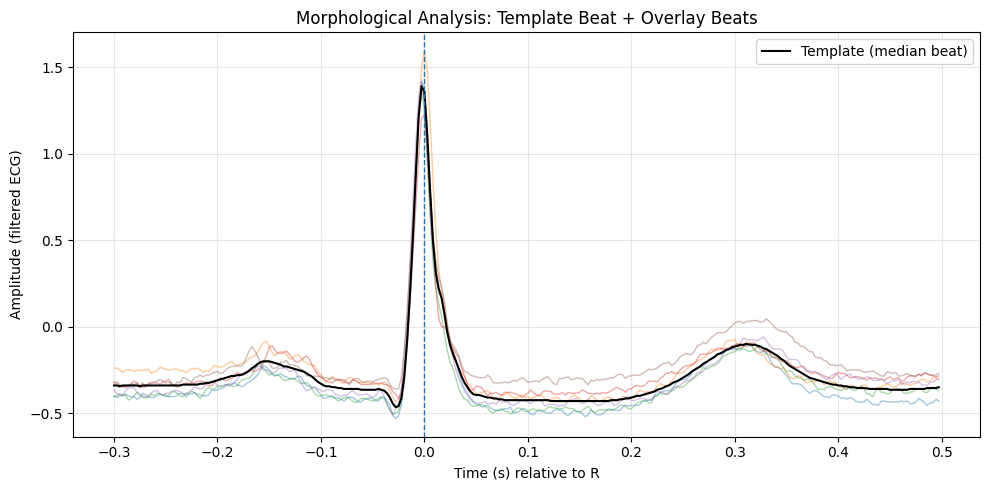

In [14]:
# Tính template beat (median beat)
template = np.median(beats, axis=0)

# Vẽ overlay beats + template
np.random.seed(0)
num_overlay = min(6, len(beats))
overlay_idx = np.random.choice(len(beats), num_overlay, replace=False)
overlay_beats = beats[overlay_idx]

plt.figure(figsize=(10, 5))

# Overlay beats (mờ)
for b in overlay_beats:
    plt.plot(t_beat, b, alpha=0.4, linewidth=1)

# Template beat (đậm)
plt.plot(t_beat, template, color="black", linewidth=1.5, label="Template (median beat)")

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Morphological Analysis: Template Beat + Overlay Beats")
plt.xlabel("Time (s) relative to R")
plt.ylabel("Amplitude (filtered ECG)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Tính correlation với template để phát hiện beat bất thường
def corr_with_template(x, m):
    """Tính correlation giữa beat và template"""
    x0 = x - np.mean(x)
    m0 = m - np.mean(m)
    return np.dot(x0, m0) / (np.linalg.norm(x0) * np.linalg.norm(m0))

corrs = np.array([corr_with_template(b, template) for b in beats])

print("Correlation stats:")
print("  min:", np.min(corrs))
print("  mean:", np.mean(corrs))
print("  max:", np.max(corrs))

Correlation stats:
  min: -0.4785417346921484
  mean: 0.9741054463662471
  max: 0.998438254081339


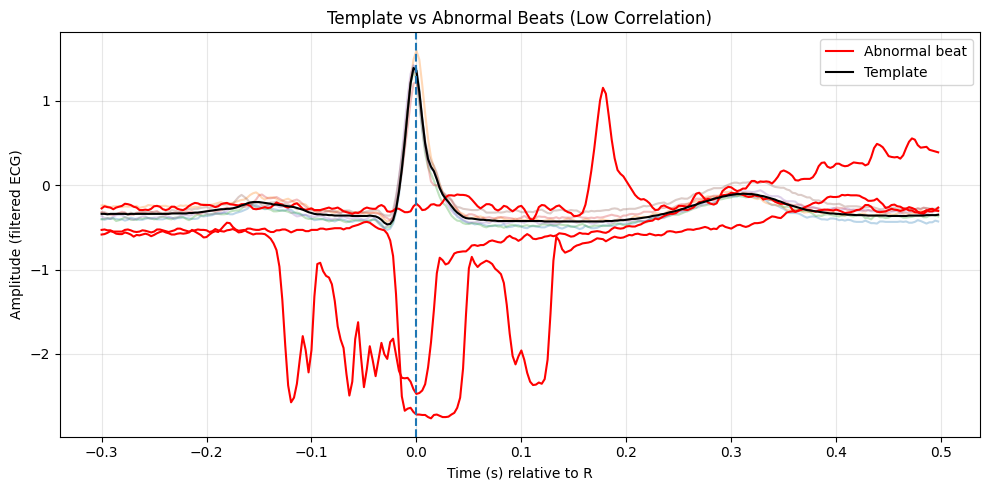

In [16]:
# Vẽ beats bình thường vs bất thường (low correlation)
num_abnormal = min(3, len(beats))
abnormal_idx = np.argsort(corrs)[:num_abnormal]

plt.figure(figsize=(10, 5))

# Beats bình thường (random)
for b in overlay_beats:
    plt.plot(t_beat, b, alpha=0.3)

# Beats bất thường (corr thấp)
for i in abnormal_idx:
    plt.plot(t_beat, beats[i], color="red", linewidth=1.5,
             label="Abnormal beat" if i == abnormal_idx[0] else None)

# Template
plt.plot(t_beat, template, color="black", linewidth=1.5, label="Template")

plt.axvline(0, linestyle="--")
plt.title("Template vs Abnormal Beats (Low Correlation)")
plt.xlabel("Time (s) relative to R")
plt.ylabel("Amplitude (filtered ECG)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. QRS Feature Extraction

In [17]:
# Trích xuất đặc trưng QRS đơn giản
def extract_qrs_features_simple(ecg, r_peaks, fs):
    """Trích xuất các đặc trưng Q/R/S"""
    # Q: min trong [R-40ms, R-5ms]
    # S: min trong [R+5ms, R+60ms]
    q_left  = int(0.040 * fs)
    q_right = int(0.005 * fs)
    s_left  = int(0.005 * fs)
    s_right = int(0.060 * fs)

    feats = []
    r_peaks = np.asarray(r_peaks, dtype=int)

    for r in r_peaks:
        if r - q_left < 0 or r + s_right >= len(ecg):
            continue

        q_lo = r - q_left
        q_hi = r - q_right
        q_idx = q_lo + int(np.argmin(ecg[q_lo:q_hi]))

        s_lo = r + s_left
        s_hi = r + s_right
        s_idx = s_lo + int(np.argmin(ecg[s_lo:s_hi]))

        feats.append({
            "r_idx": int(r),
            "q_idx": int(q_idx),
            "s_idx": int(s_idx),
            "A_Q": float(ecg[q_idx]),
            "A_R": float(ecg[r]),
            "A_S": float(ecg[s_idx]),
            "QRS_width_ms": float((s_idx - q_idx) * 1000.0 / fs),
        })

    return pd.DataFrame(feats)

# Trích xuất QRS features
df_qrs = extract_qrs_features_simple(ecg_raw, r_peaks, fs)
display(df_qrs.head(10))
print("\nQRS width statistics (ms):")
print(df_qrs["QRS_width_ms"].describe())

,r_idx,q_idx,s_idx,A_Q,A_R,A_S,QRS_width_ms
0,83,73,103,-0.400,1.065,-0.435,83.333333
1,396,389,413,-0.370,1.020,-0.405,66.666667
2,711,702,731,-0.370,1.165,-0.375,80.555556
3,1032,1023,1051,-0.465,1.095,-0.455,77.777778
4,1368,1359,1386,-0.490,1.100,-0.485,75.000000
5,1712,1702,1728,-0.430,1.000,-0.480,72.222222
6,2036,2023,2052,-0.545,1.065,-0.590,80.555556
7,2349,2341,2369,-0.450,1.375,-0.405,77.777778
8,2662,2654,2680,-0.365,1.305,-0.320,72.222222
9,2972,2963,2992,-0.445,1.220,-0.450,80.555556



QRS width statistics (ms):
count    1873.000000
mean       77.782227
std         5.506743
min         8.333333
25%        75.000000
50%        77.777778
75%        80.555556
max        94.444444
Name: QRS_width_ms, dtype: float64


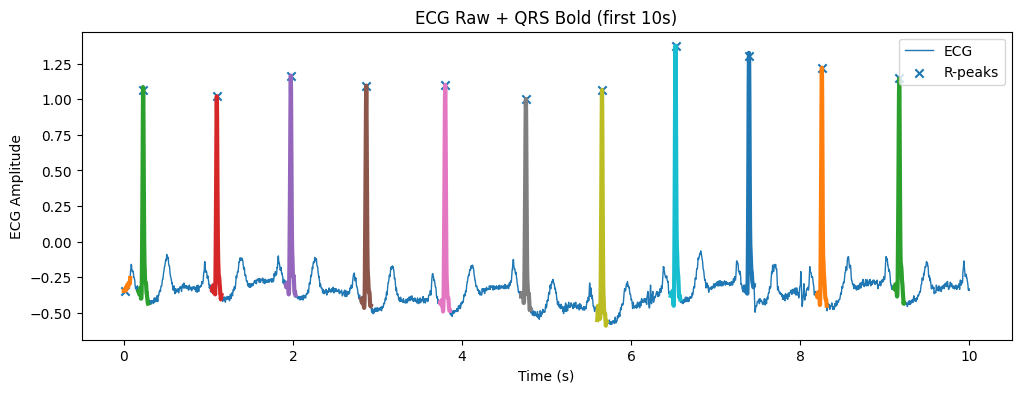

In [18]:
# Vẽ ECG với QRS in đậm
def plot_ecg_qrs_bold_window(ecg, fs, r_peaks, seconds=10, qrs_window_ms=120):
    """In đậm QRS bằng cách lấy cửa sổ cố định quanh mỗi R-peak"""
    n = int(seconds * fs)
    ecg_seg = ecg[:n]
    t = np.arange(n) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(t, ecg_seg, linewidth=1, label="ECG")

    half = int((qrs_window_ms / 1000) * fs / 2)

    # In đậm các đoạn quanh R-peak
    for r in r_peaks:
        if r >= n:
            break
        s = max(0, r - half)
        e = min(n - 1, r + half)
        plt.plot(t[s:e], ecg_seg[s:e], linewidth=3)  # "in đậm"

    rp = np.array(r_peaks)
    rp = rp[rp < n]
    plt.scatter(rp / fs, ecg[rp], marker="x", label="R-peaks")

    plt.title(f"ECG Raw + QRS Bold (first {seconds}s)")
    plt.xlabel("Time (s)")
    plt.ylabel("ECG Amplitude")
    plt.legend()
    plt.show()

# Vẽ ECG với QRS đậm
plot_ecg_qrs_bold_window(ecg_raw, fs=fs, r_peaks=r_peaks, seconds=10, qrs_window_ms=120)

In [19]:
# Thống kê label annotation cho record 100, 101
for rec in ["100", "101"]:
    ann = wfdb.rdann(rec, "atr", pn_dir="mitdb")
    symbols = pd.Series(ann.symbol)
    
    print(f"\n=== Record {rec} ===")
    print("Unique labels:")
    print(sorted(symbols.unique()))
    print("\nLabel counts:")
    print(symbols.value_counts())


=== Record 100 ===
Unique labels:
['+', 'A', 'N', 'V']

Label counts:
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

=== Record 101 ===
Unique labels:
['+', 'A', 'N', 'Q', '|', '~']

Label counts:
N    1860
~       4
|       4
A       3
Q       2
+       1
Name: count, dtype: int64


Record 100 contains labels: ['N', 'V', 'A']


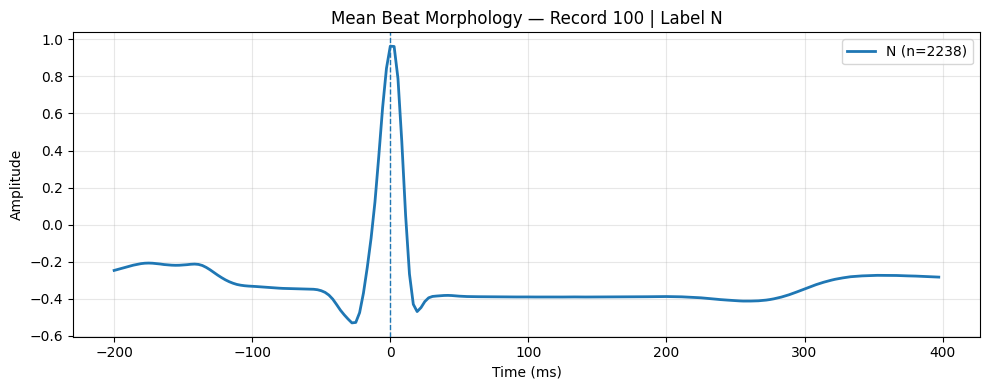

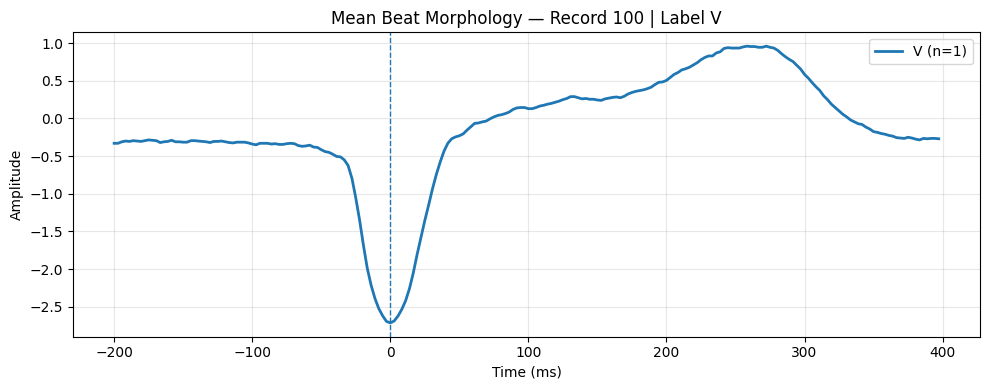

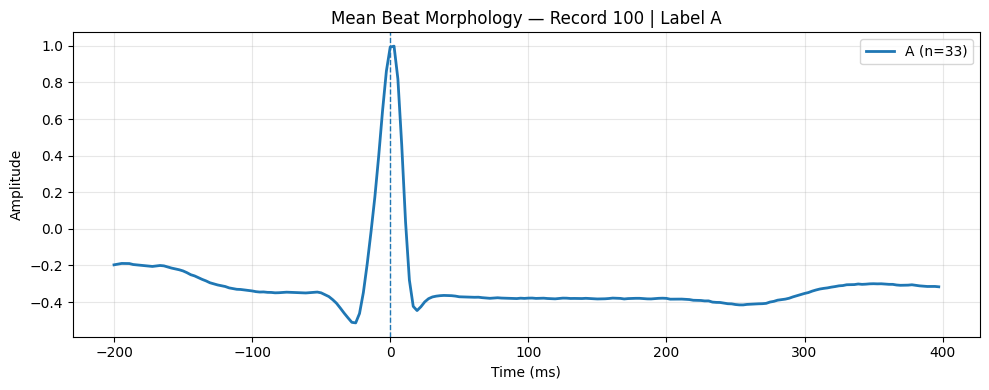

Record 101 contains labels: ['N', 'A']


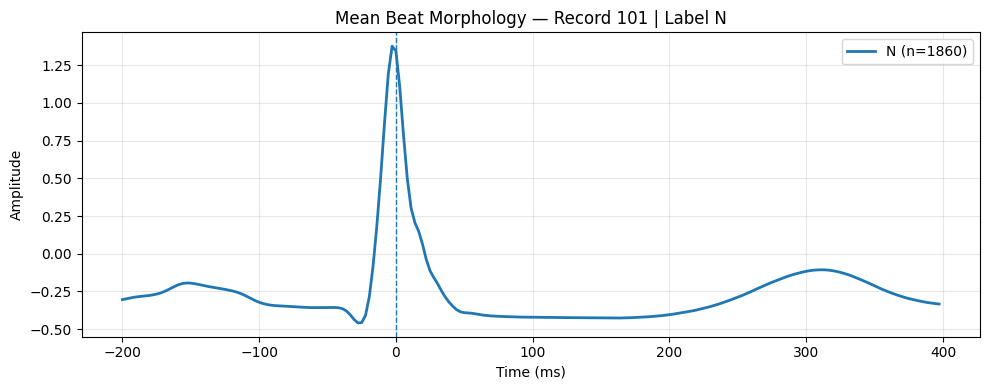

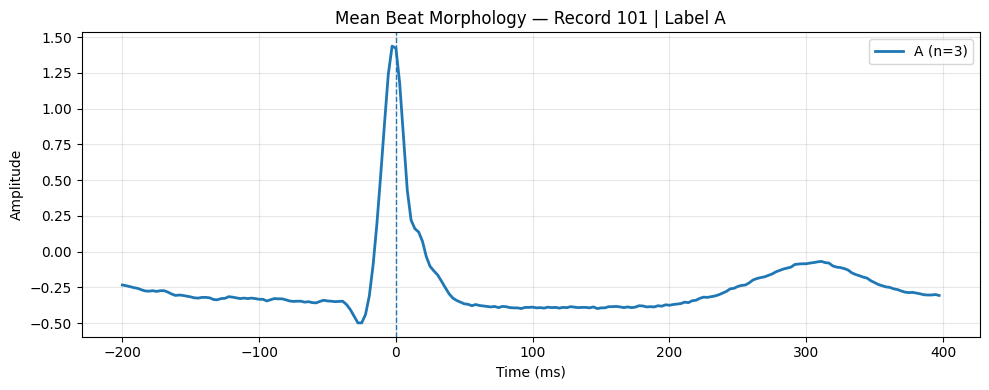

In [20]:
# Vẽ mean beat morphology cho mỗi label
def plot_available_beats(record_name="100",
                         labels=("N", "V", "A", "L", "R"),
                         window_ms=(-200, 400)):
    """Plot mean beat morphology cho từng label"""
    # Load record + annotation
    rec = wfdb.rdrecord(record_name, pn_dir="mitdb")
    ann = wfdb.rdann(record_name, "atr", pn_dir="mitdb")

    fs = rec.fs
    sig = rec.p_signal[:, 0]

    # Find which labels exist in this record
    available = sorted(set(ann.symbol))
    use_labels = [lab for lab in labels if lab in available]

    if not use_labels:
        print("No target labels found in record.")
        return

    print(f"Record {record_name} contains labels:", use_labels)

    # Window size
    left = int(window_ms[0] * fs / 1000)
    right = int(window_ms[1] * fs / 1000)
    t_ms = (np.arange(right - left) / fs) * 1000 + window_ms[0]

    for label in use_labels:
        segments = []

        for s, sym in zip(ann.sample, ann.symbol):
            if sym == label:
                a = s + left
                b = s + right
                if a >= 0 and b <= len(sig):
                    segments.append(sig[a:b])

        if len(segments) == 0:
            continue

        segments = np.array(segments, dtype=np.float64)
        mean_wave = segments.mean(axis=0)

        # --- Plot riêng từng label ---
        plt.figure(figsize=(10, 4))
        plt.plot(t_ms, mean_wave, linewidth=2, label=f"{label} (n={len(segments)})")
        plt.axvline(0, linestyle="--", linewidth=1)
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude")
        plt.title(f"Mean Beat Morphology — Record {record_name} | Label {label}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Vẽ mean beat morphology cho record 100 và 101
plot_available_beats("100")
plot_available_beats("101")